## 1) Imports


In [126]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import warnings
from collections import defaultdict
import time
from collections import Counter

# ── Numerical / data ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import h5py
import scipy.stats


# ── Graph ─────────────────────────────────────────────────────────────────────
import networkx as nx
from tqdm.notebook import tqdm


# ── Statistics ────────────────────────────────────────────────────────────────
from scipy.stats import mannwhitneyu
# ARI (Adjusted Rand Index): measures overlap between two partitions corrected for chance.
# NMI (Normalized Mutual Information): information-theoretic overlap, insensitive to community count.
# We compute both because ARI penalises splits/merges more harshly than NMI.
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# ── Brain atlas & visualisation ───────────────────────────────────────────────
import nibabel as nib
from nilearn import datasets, plotting, image
from nilearn.maskers import NiftiLabelsMasker

# ── Plotting ──────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.colors import ListedColormap

from pathlib import Path
import os


warnings.filterwarnings('ignore')   # suppress nilearn cache / deprecation noise


---
## 2) Config


In [15]:
# walk upward from current dir till we find project folder
def find_project_root(marker='README.md'):
    path = Path(os.getcwd())
    for src in [path, *path.parents]:
        if (src / marker).exists():
            return src
    raise FileNotFoundError(
        f'Could not find the project root. Looked for {marker} starting from {path}.'
    )
    
PROJ_ROOT = find_project_root()
DB_PATH = PROJ_ROOT / 'SMA_data_processing' / 'cobre_combined_connectomes_database.h5'


GAMMA = 1.0 #louvain resolution, 1.0 is standard
THRESHOLD = 1e-3 # modularity convergence threshold
MAX_LEVELS=1000 #louvain lvls
RANDOM_SEED= 42 #for reproductibility

PALETTE = {'HC': '#4C9BE8', 'SCZ': '#E8734C'}


---
## 3) Louvain functions from Louvain.ipynb

- initial_assignment_communities: partition, every node is its own community
- delta_q: computes modularity gain for moving one node into a candidate community
- louvain_step_one: local optimisation phase (iter until no node moves)
- louvain_step_two: graph coarsening (collapse communities into super-nodes)
- modularity: computes standard Newman-Girvan Q score
- louvain: runs the full two-phase loop until convergence


In [54]:
def initial_assignment_communities(G):
    return {node: node for node in G.nodes()}

def delta_q(G, node, target_community, communities, gamma=1.0, weight='weight'):
    degrees= dict(G.degree(weight=weight))
    two_m= sum(degrees.values())
    k_i_in= sum( #sum the weights of the neighbors of a node
        edge_data.get(weight,0)
        for neighbor, edge_data in G[node].items() # [node] is the lookup key, not a syntactic marker meaning "give me nodes" --> specific node
        if neighbor != node and communities[neighbor] ==target_community
    )
    
    k_i= degrees[node]
    
    sigma_tot=sum( #sum of degrees of all neighbors from the target_community
        degrees[n]
        for n in G.nodes() # all nodes
        if n!= node and communities[n] == target_community
    )
    
    return (k_i_in/two_m) - gamma * (sigma_tot * k_i) / (two_m **2)


def louvain_step_one(G, gamma=1.0, weight='weight'):
    """
    Phase 1 of Louvain — local modularity optimisation.
    """
    communities = initial_assignment_communities(G)

    # Pre-compute degrees once — O(edges)
    degrees = dict(G.degree(weight=weight))
    two_m   = sum(degrees.values())

    if two_m == 0:
        return communities   # empty graph — nothing to do

    # community_total_degree[c] = sum of degrees of all nodes in community c
    # Initialised with each node in its own community → equals its own degree
    community_total_degree = {node: degrees[node] for node in G.nodes()}

    moved = True
    while moved:
        moved = False

        for node in G.nodes():
            current_community = communities[node]
            k_i               = degrees[node]

            # --- temporarily remove node from its current community ----------
            communities[node]                          = -1
            community_total_degree[current_community] -= k_i

            # --- find unique neighboring communities -------------------------
            # We only need to consider communities of actual neighbors —
            # no need to scan all n nodes.
            neighbor_communities = {}   # {community_id: k_i_in (edge weight sum)}
            for neighbor, edge_data in G[node].items():
                nc = communities[neighbor]
                if nc == -1:
                    continue   # skip if neighbor is also isolated (shouldn't happen)
                w = edge_data.get(weight, 0)
                if nc not in neighbor_communities:
                    neighbor_communities[nc] = 0.0
                neighbor_communities[nc] += w

            # --- evaluate delta_q for each neighboring community -------------
            # Formula: delta_q = k_i_in/2m - gamma * sigma_tot * k_i / (2m)²
            # All quantities are now O(1) lookups — no inner loops.
            best_community = current_community
            best_dq        = 0.0   # only move if gain is strictly positive

            for tc, k_i_in in neighbor_communities.items():
                sigma_tot = community_total_degree.get(tc, 0.0)
                dq = (k_i_in / two_m) - gamma * (sigma_tot * k_i) / (two_m ** 2)
                if dq > best_dq:
                    best_dq        = dq
                    best_community = tc

            # --- place node into best community and update cache -------------
            communities[node]                         = best_community
            community_total_degree[best_community]    = \
                community_total_degree.get(best_community, 0.0) + k_i

            if best_community != current_community:
                moved = True

    return communities
    
    
def louvain_step_two(G, communities, weight= 'weight'): #each community becomes a super-node
    new_G= nx.Graph() # .Graph with Capital letter!!!
    for uc in set(communities.values()):
        new_G.add_node(uc)
    
    for n1,n2,edge_data in G.edges(data=True):
        c1, c2 = communities[n1], communities[n2]
        w= edge_data.get(weight,0)
        if new_G.has_edge(c1,c2):
            new_G[c1][c2][weight] += w #adds current edge's weight to the running total
        else:
            new_G.add_edge(c1,c2, **{weight:w}) #1st time we encounter an edge between these 2 communities we create a super-edge between them with current weight as starting value
    return new_G


def modularity(G, communities, weight='weight', gamma=1.0):
    """
    Compute Newman-Girvan modularity Q in O(edges) instead of O(n²).

    Standard reformulation:
        Q = (1/2m) Σ_c [ L_c  -  gamma * D_c² / (2m) ]

    where for each community c:
        L_c = sum of weights of edges with BOTH endpoints in c
        D_c = sum of degrees (weighted) of all nodes in c

    This avoids the double loop over all node pairs entirely.
    """
    degrees = dict(G.degree(weight=weight))
    two_m   = sum(degrees.values())

    if two_m == 0:
        return 0.0

    # Accumulate L_c and D_c per community
    community_L = defaultdict(float)   # internal edge weight sum
    community_D = defaultdict(float)   # total degree sum

    for node, comm in communities.items():
        community_D[comm] += degrees[node]

    for u, v, data in G.edges(data=True):
        if communities[u] == communities[v]:
            w = data.get(weight, 0)
            community_L[communities[u]] += w   # each edge counted once

    Q = 0.0
    for comm in community_D:
        L_c = community_L.get(comm, 0.0)
        D_c = community_D[comm]
        # multiply L_c by 2 because each internal edge contributes to
        # both endpoints in the original double-sum formulation
        Q += (2 * L_c / two_m) - gamma * (D_c / two_m) ** 2

    return Q


        
def louvain(G, weight='weight', threshold=1e-3, max_levels=1000, gamma=1.0):
    """
    Full Louvain algorithm using the optimised phase 1 and O(edges) modularity.
    Returns dict {original_node: community_id} after convergence.

    Complexity: O(edges × n_passes × n_levels) — same class as NetworkX.
    Still pure Python so expect ~5-10x slower than NetworkX in wall time,
    but now finishes in minutes rather than days at n=1019.
    """
    current_G  = G
    levels     = 0
    prev_Q     = -1.0

    # Track mapping from original node → current super-node
    communities_original = {node: node for node in G.nodes()}

    while levels < max_levels:
        communities = louvain_step_one(current_G, gamma=gamma, weight=weight)
        curr_Q      = modularity(current_G, communities,
                                      weight=weight, gamma=gamma)

        if prev_Q != -1.0 and abs(curr_Q - prev_Q) < threshold: #if its insignificant, ignore
            break

        prev_Q    = curr_Q
        new_G     = louvain_step_two(current_G, communities, weight=weight)

        # Propagate mapping back to original nodes
        communities_original = {
            orig: communities[old_comm]
            for orig, old_comm in communities_original.items() #old_comm is actually the current community orig node is with after level 1
        }

        current_G = new_G
        levels   += 1

    return communities_original



## ------- ----------------------------- HELPER FUNCTIONS ---------------------------------
# ── Helper: dict → list-of-sets (format expected by nx.modularity) 
def communities_to_sets(communities_dict):
    grouped = defaultdict(set)
    for node, cid in communities_dict.items():
        grouped[cid].add(node)
    return list(grouped.values())


# ── Helper: dict → flat label array (format expected by sklearn metrics)
def communities_to_labels(communities_dict):
    """
    Returns a numpy array where index = node (assumes nodes are 0..N-1)
    and value = community id remapped to 0..K-1.
    """
    nodes = sorted(communities_dict.keys())
    raw   = np.array([communities_dict[n] for n in nodes])
    # remap community ids to contiguous integers
    unique = {v: i for i, v in enumerate(sorted(set(raw)))}
    return np.array([unique[v] for v in raw])


print('Louvain functions loaded.')

Louvain functions loaded.


---
## Cell 3) Load the HDF5 Database and Build Graphs

Diagnostic cell to see the keys and their shapes in the db

In [55]:
with h5py.File(DB_PATH, 'r') as f:
    print('keys in db:', list(f.keys()))
    for key in f.keys():
        print(f' {key}: shape={f[key].shape}, dtype={f[key].dtype}')

keys in db: ['hc_glasso', 'hc_pearson', 'scz_glasso', 'scz_pearson']
 hc_glasso: shape=(73, 1019, 1019), dtype=float64
 hc_pearson: shape=(73, 1019, 1019), dtype=float32
 scz_glasso: shape=(72, 1019, 1019), dtype=float64
 scz_pearson: shape=(72, 1019, 1019), dtype=float32


Store the graph and raw matrices for later use (needed for computing group-avg matrices and for the healing sim). The raw marix is needed to compute element-wise group averages and to zero out specific edges during the healing sim. 

In [56]:
graphs_hc_glasso, graphs_scz_glasso = [],[]
graphs_hc_pearson,graphs_scz_pearson =[],[]
matrices_hc_glasso, matrices_scz_glasso= [],[]
matrices_hc_pearson,matrices_scz_pearson=[],[]

PEARSON_THRESHOLD= 0.3
BAD_COLS= [1009,1010] #artifact ROIS that have been forgotten to be removed in the preprocessing (right cerebral white matter and right cerebral cortex)

def mask_bad_rois(A, bad_cols):
    A = A.copy()
    for c in bad_cols:
        A[c, : ] = 0.0
        A[:,c]= 0.0
    return A

with h5py.File(DB_PATH, 'r') as f:
    print("loading glasso matrices..")
    
    # Glasso
    for i in range(f['hc_glasso'].shape[0]):
        A = f['hc_glasso'][i].astype(np.float64)
        np.fill_diagonal(A,0)
        A=mask_bad_rois(A, BAD_COLS)
        matrices_hc_glasso.append(A)
        graphs_hc_glasso.append(nx.from_numpy_array(A))
        
    for i in range(f['scz_glasso'].shape[0]):
        A = f['scz_glasso'][i].astype(np.float64)
        np.fill_diagonal(A, 0)
        A = mask_bad_rois(A, BAD_COLS)
        matrices_scz_glasso.append(A)
        graphs_scz_glasso.append(nx.from_numpy_array(A))

        # Pearson
    for i in tqdm(range(f['hc_pearson'].shape[0]), desc='HC Pearson'):
        A = f['hc_pearson'][i].astype(np.float64)
        A[np.abs(A) < PEARSON_THRESHOLD] = 0
        A = np.abs(A)                          
        np.fill_diagonal(A, 0)
        A = mask_bad_rois(A, BAD_COLS)
        matrices_hc_pearson.append(A)
        graphs_hc_pearson.append(nx.from_numpy_array(A))

    for i in tqdm(range(f['scz_pearson'].shape[0]), desc='SCZ Pearson'):
        A = f['scz_pearson'][i].astype(np.float64)
        A[np.abs(A) < PEARSON_THRESHOLD] = 0
        A = np.abs(A)                         
        np.fill_diagonal(A, 0)
        A = mask_bad_rois(A, BAD_COLS)
        matrices_scz_pearson.append(A)
        graphs_scz_pearson.append(nx.from_numpy_array(A))
        
        
matrices_hc_glasso   = np.array(matrices_hc_glasso)
matrices_scz_glasso  = np.array(matrices_scz_glasso)
matrices_hc_pearson  = np.array(matrices_hc_pearson)
matrices_scz_pearson = np.array(matrices_scz_pearson)

N_HC = len(graphs_hc_glasso)
N_SCZ= len(graphs_scz_glasso)
N_ROI = matrices_hc_glasso.shape[1]

'''example of .shape[]
matrices_hc_glasso.shape  →  (73, 1019, 1019)
                              ↑    ↑     ↑
                         shape[0] shape[1] shape[2]
'''

# -----------------------------HERE IMPORTANT: WE ARE USING GLASSO FOR THE DOWNSTREAM CELLS--------------------------------------
'''Glasso is sparser graphs, partial correlations, less prone to outliers. It is the more conservative choice, 
and the published literature on functional connectivity in schizophrenia generally uses Glasso or similar sparsification'''
graphs_hc    = graphs_hc_glasso
graphs_scz   = graphs_scz_glasso
matrices_hc  = matrices_hc_glasso
matrices_scz = matrices_scz_glasso
# -------------------------------MODIF TO PEARSON HERE IF U WANT-----------------------------------------------------------------


# Diagnostic: average edge counts to confirm sparsification worked
avg_glasso_edges  = np.mean([g.number_of_edges() for g in graphs_hc_glasso])
avg_pearson_edges = np.mean([g.number_of_edges() for g in graphs_hc_pearson])

print(f'\nHC subjects : {N_HC}, SCZ subjects : {N_SCZ}, ROIs : {N_ROI}')
print(f'Avg edges per graph — Glasso  : {avg_glasso_edges:>10,.0f}')
print(f'Avg edges per graph — Pearson : {avg_pearson_edges:>10,.0f}  (after threshold)')
print(f'Memory used: {(matrices_hc_glasso.nbytes + matrices_hc_pearson.nbytes + matrices_scz_glasso.nbytes + matrices_scz_pearson.nbytes) / 1e9:.2f} GB')

loading glasso matrices..


HC Pearson:   0%|          | 0/73 [00:00<?, ?it/s]

SCZ Pearson:   0%|          | 0/72 [00:00<?, ?it/s]


HC subjects : 73, SCZ subjects : 72, ROIs : 1019
Avg edges per graph — Glasso  :      5,542
Avg edges per graph — Pearson :    152,829  (after threshold)
Memory used: 2.41 GB


---
## Cell 4) Load Atlas Metadata (ROI Coordinates and Names)

To build 3D brain visualisations we need:
1. **MNI coordinates** of each ROI centroid for placing nodes on the glass brain
2. **Anatomical names** for labelling bridge nodes



In [58]:
# With 1019 ROIs the atlas combination is:
#   - Schaefer 2018 at 1000 parcels (cortical, 7-network solution)
#   - Harvard-Oxford subcortical atlas (19 ROIs after cleaning)

atlas_schaefer = datasets.fetch_atlas_schaefer_2018(n_rois=1000, resolution_mm=2)
atlas_ho       = datasets.fetch_atlas_harvard_oxford('sub-maxprob-thr25-2mm')

# ── Schaefer 1000: build label list ──────────────────────────────────────────
schaefer_labels = [
    lbl.decode() if isinstance(lbl, bytes) else lbl
    for lbl in atlas_schaefer.labels
][1:] #drop index 0 which is background and not a real parcel

assert len(schaefer_labels) == 1000, \
    f'expected 1000 Schaefer labels after dropping Background, got {len(schaefer_labels)}'
    

# Schaefer 1000: compute parcel centroids in MNI space: for each parcel, find all voxels with that label
# value in the image, average their voxel-space indices, then apply the affine transform to convert to MNI mm coordinates

schaefer_img = nib.load(atlas_schaefer.maps)
schaefer_data  =schaefer_img.get_fdata()
affine = schaefer_img.affine


def compute_centroid_mni(label_img_data, affine, label_id):
    """
    Returns the MNI coordinate (mm) of the centroid of a parcel.

    Parameters
    ----------
    label_img_data : np.ndarray  3D voxel array of integer label values
    affine         : np.ndarray  4x4 affine matrix from the NIfTI header
    label_id       : int         the label value to find in the image

    Returns
    -------
    np.ndarray of shape (3,) — [x, y, z] in MNI mm space
    """
    
    voxels = np.argwhere(label_img_data == label_id) # (n_voxels , 3)
    if len(voxels) == 0: #parcel exists in the list but has no voxels
        return np.arry([0.0,0.0,0.0]) #make it appear here
    centroid_vox = voxels.mean(axis=0) #mean voxel index
    centroid_mni = affine[:3,:3] @ centroid_vox + affine[:3, 3]
    return centroid_mni
            

print('Computing Schaefer 1000 centroids...')
schaefer_coords = np.array([
    compute_centroid_mni(schaefer_data, affine, label_id=i+1)
    for i in range(1000)   # label values 1..1000 in the image
])
print(f'Schaefer centroids computed: {schaefer_coords.shape}')

[fetch_atlas_schaefer_2018] Dataset found in C:\Users\anabo\nilearn_data\schaefer_2018
[fetch_atlas_harvard_oxford] Dataset found in C:\Users\anabo\nilearn_data\fsl
Computing Schaefer 1000 centroids...
Schaefer centroids computed: (1000, 3)


In [59]:
# ── Harvard-Oxford subcortical: same as before, flag the 2 artifact ROIs with 'ARTIFACT'────

if isinstance(atlas_ho.maps, str):
    ho_img= nib.load(atlas_ho.maps)
else: ho_img=atlas_ho.maps

ho_data = ho_img.get_fdata().copy()
ho_affine=ho_img.affine

#remove values 1 and 2 for the preprocessing
ho_data[ho_data ==1]=0
ho_data[ho_data ==2]=0


ho_labels_raw = [lbl.decode() if isinstance(lbl, bytes) else lbl
                 for lbl in atlas_ho.labels]

ho_unique_labels = sorted ([int(v) for v in np.unique(ho_data) if v>0])

#build label list, flag the 2 artifacts
ARTEFACT_NAMES= {'Right Cerebral White Matter', 'Right Cerebral Cortex'}

ho_labels=[]
for lid in ho_unique_labels:
    name = ho_labels_raw[lid]
    if name in ARTEFACT_NAMES:
        ho_labels.append(f'[ARTEFACT] {name}')
    else: ho_labels.append(name)
    
    
    
#COMPUTE HO CENTROIDS
ho_coords = np.array([
    compute_centroid_mni(ho_data, ho_affine, label_id = lid)
    for lid in ho_unique_labels
])


In [60]:
#CONCAT SCHAEFER 1000 + HO SUBCORTICAL 19
    #cols 0 -> 999 are Schaefer cortical ROIS
    #cols 1000 -> 1018 are HO subcortical ROIs

all_coords= np.vstack([schaefer_coords, ho_coords]) # ( 1019, 3)
all_labels = schaefer_labels + ho_labels # =1019

print( "Schaefer ROIs: " ,{len(schaefer_labels)})
print("HO subcortical ROIs: " ,{len(ho_labels)})
print("Total atlas ROIs: ", {len(all_labels)})
print("Graph nodes (N_ROI): " , {N_ROI})

Schaefer ROIs:  {1000}
HO subcortical ROIs:  {19}
Total atlas ROIs:  {1019}
Graph nodes (N_ROI):  {1019}


In [61]:
# build VALID_ROI_MASK (boolean array of shape (N_ROI, ))
    #true = real brain ROI, false = artifact
    # if we would delete the artifact nodes instead all mapping between matrix col i and all_coords[i] etc. would shift all indices and would be wrong

VALID_ROI_MASK = np.array(['[ARTEFACT]' not in l for l in all_labels])

artefact_indices = np.where(~VALID_ROI_MASK)[0] # ~ is the bitwise NOT operator in python
print(f'\nValid ROIs for analysis : {VALID_ROI_MASK.sum()} / {N_ROI}')
print(f'Artefact ROIs excluded  : {(~VALID_ROI_MASK).sum()}')
for idx in artefact_indices:
    print(f'  column {idx} → {all_labels[idx]}')



print('\nValid HO subcortical ROIs:')
for i, (lid, name) in enumerate(zip(ho_unique_labels, ho_labels)):
    col = 1000 + i
    if VALID_ROI_MASK[col]:
        print(f'  col {col:4d}  label_id={lid:2d}  {name}')

print('\nAtlas metadata ready.')


Valid ROIs for analysis : 1017 / 1019
Artefact ROIs excluded  : 2
  column 1009 → [ARTEFACT] Right Cerebral White Matter
  column 1010 → [ARTEFACT] Right Cerebral Cortex

Valid HO subcortical ROIs:
  col 1000  label_id= 3  Left Lateral Ventricle
  col 1001  label_id= 4  Left Thalamus
  col 1002  label_id= 5  Left Caudate
  col 1003  label_id= 6  Left Putamen
  col 1004  label_id= 7  Left Pallidum
  col 1005  label_id= 8  Brain-Stem
  col 1006  label_id= 9  Left Hippocampus
  col 1007  label_id=10  Left Amygdala
  col 1008  label_id=11  Left Accumbens
  col 1011  label_id=14  Right Lateral Ventricle
  col 1012  label_id=15  Right Thalamus
  col 1013  label_id=16  Right Caudate
  col 1014  label_id=17  Right Putamen
  col 1015  label_id=18  Right Pallidum
  col 1016  label_id=19  Right Hippocampus
  col 1017  label_id=20  Right Amygdala
  col 1018  label_id=21  Right Accumbens

Atlas metadata ready.


---
## Cell 5) Compute the HC Consensus (Reference) Partition

We need a Ground Truth community structure representing a healthy brain. We will achieve it using Louvain on the element-wise mean HC matrix. The mean matrix represents the avg functional coupling across all healthy subjects. the resulting partition is the 'typical healthy community structure'. 
- Limitations: the mean smooths over inter-subject variability in HC
- alternatives: Consensus clustering across all HC subjects (run Louvain on each HC indvidually, build a co-assignement matrix (P[i,j] = fraction of HC subjects where ROI i and ROI j are in the same community, then threshold and recluster)) 

In [78]:
print('Starting custom Louvain algo on mean HC matrix using GLASSO...')

mean_hc_matrix = np.abs(matrices_hc.mean(axis=0))
np.fill_diagonal(mean_hc_matrix, 0)
G_mean_hc_glasso = nx.from_numpy_array(mean_hc_matrix)

hc_ref_sets_glasso = communities_to_sets(
    louvain(
        G_mean_hc_glasso,
        weight='weight',
        threshold=THRESHOLD,
        max_levels=MAX_LEVELS,
        gamma=GAMMA
    )
)

hc_ref_partition_glasso= {
    node:cid # cid is community_id, this is a dict with key:value
    for cid ,s in enumerate(hc_ref_sets_glasso)
    for node in s
}

q_ref_glasso = modularity(G_mean_hc_glasso, hc_ref_partition_glasso, gamma=GAMMA)
n_comm= len(hc_ref_sets_glasso)
sizes= sorted ([len(s) for s in hc_ref_sets_glasso], reverse=True)

print(f'Custom louvain : {n_comm} communities  '
      f'Q={q_ref_glasso:.4f}')

Starting custom Louvain algo on mean HC matrix using GLASSO...
Custom louvain : 12 communities  Q=0.6277


In [77]:
print('Starting custom Louvain algo on mean HC matrix using PEARSON...')

mean_hc_matrix_pearson = np.abs(matrices_hc_pearson.mean(axis=0))
np.fill_diagonal(mean_hc_matrix, 0) #fill diag with 0s
G_mean_hc_pearson = nx.from_numpy_array(mean_hc_matrix_pearson)

hc_ref_sets_pearson = communities_to_sets(
    louvain(
        G_mean_hc_pearson,
        weight= 'weight',
        threshold= PEARSON_THRESHOLD,
        max_levels=MAX_LEVELS,
        gamma=GAMMA
    )
)
hc_ref_partition_pearson={
    node: cid
    for cid, s in enumerate(hc_ref_sets_pearson)
    for node in s
}

q_ref_pearson = modularity(G_mean_hc_pearson, hc_ref_partition_pearson, gamma=GAMMA)
print(f'Pearson reference: {len(hc_ref_sets_pearson)} communities  Q={q_ref_pearson:.4f}')




Starting custom Louvain algo on mean HC matrix using PEARSON...
Pearson reference: 6 communities  Q=0.1586


(NOT IMPLEMENTED YET) Comparaison against NetworkX Louvain community algo
- compare for Q score, Adjusted Rand Index (ARI) and Normalized Mutual Information (NMI). Both are external validation metrics used to evaluate the performance of clustering algorithms by comparing predicted clusters against "ground truth" labels

In [65]:
# for this to work i neet to implement networkX community algo too, NMI and ARI measure how similar 2 partitions are to each other for validation purposes

'''common_nodes = sorted(
    set(hc_ref_partition.keys()))

custom_arr     = np.array([hc_ref_partition[n]        for n in common_nodes])

ari = adjusted_rand_score(custom_arr)
nmi = normalized_mutual_info_score(custom_arr)

print()
print('── Comparison: NetworkX vs Custom ──────────────────────────')
print(f'  n_comm   : {n_comm:3d} communities  Q={q_ref:.4f}')
print(f'  ARI   : {ari:.4f}  '
      f'(1.0 = identical, 0.0 = random)')
print(f'  NMI  : {nmi:.4f}  '
      f'(1.0 = identical, 0.0 = random)')

print()
print('Note: ARI/NMI < 1.0 is expected — Louvain is non-deterministic')
print('across implementations due to node visiting order differences.')
print('Q difference < 0.01 confirms good partitions.')
'''

"common_nodes = sorted(\n    set(hc_ref_partition.keys()))\n\ncustom_arr     = np.array([hc_ref_partition[n]        for n in common_nodes])\n\nari = adjusted_rand_score(custom_arr)\nnmi = normalized_mutual_info_score(custom_arr)\n\nprint()\nprint('── Comparison: NetworkX vs Custom ──────────────────────────')\nprint(f'  n_comm   : {n_comm:3d} communities  Q={q_ref:.4f}')\nprint(f'  ARI   : {ari:.4f}  '\n      f'(1.0 = identical, 0.0 = random)')\nprint(f'  NMI  : {nmi:.4f}  '\n      f'(1.0 = identical, 0.0 = random)')\n\nprint()\nprint('Note: ARI/NMI < 1.0 is expected — Louvain is non-deterministic')\nprint('across implementations due to node visiting order differences.')\nprint('Q difference < 0.01 confirms good partitions.')\n"

In [82]:
print("---------------------GLASSO: -----------------------")

q_ref = modularity(G_mean_hc_glasso, hc_ref_partition_glasso, gamma=GAMMA)
n_comm = len(hc_ref_sets_glasso)
sizes = sorted([len(s) for s in hc_ref_sets_glasso], reverse=True)
largest_frac = sizes[0] / sum(sizes)
n_singletons = sum(1 for s in hc_ref_sets_glasso if len(s) == 1) #comm of size 1

# effective number of communities (Shannon entropy)
# counts how many "real" communities there are accounting for size variation
proportions = np.array(sizes) / sum(sizes)
effective_n = np.exp(scipy.stats.entropy(proportions))

print(f'Modularity Q             : {q_ref:.4f}')
print(f'Number of communities    : {n_comm}')
print(f'Community sizes          : {sizes[:10]} ...')
print(f'Largest community size   : {sizes[0]} ({largest_frac:.1%} of nodes)')
print(f'Singleton communities    : {n_singletons}')
print(f'Effective # communities  : {effective_n:.1f}')



print("---------------------PEARSON: -----------------------")

q_ref = modularity(G_mean_hc_pearson, hc_ref_partition_pearson, gamma=GAMMA)
n_comm = len(hc_ref_sets_pearson)
sizes = sorted([len(s) for s in hc_ref_sets_pearson], reverse=True)
largest_frac = sizes[0] / sum(sizes)
n_singletons = sum(1 for s in hc_ref_sets_pearson if len(s) == 1) #comm of size 1


proportions = np.array(sizes) / sum(sizes)
effective_n = np.exp(scipy.stats.entropy(proportions))

print(f'Modularity Q             : {q_ref:.4f}')
print(f'Number of communities    : {n_comm}')
print(f'Community sizes          : {sizes[:10]} ...')
print(f'Largest community size   : {sizes[0]} ({largest_frac:.1%} of nodes)')
print(f'Singleton communities    : {n_singletons}')
print(f'Effective # communities  : {effective_n:.1f}')

---------------------GLASSO: -----------------------
Modularity Q             : 0.6277
Number of communities    : 12
Community sizes          : [178, 164, 137, 126, 109, 95, 73, 63, 60, 12] ...
Largest community size   : 178 (17.5% of nodes)
Singleton communities    : 2
Effective # communities  : 8.9
---------------------PEARSON: -----------------------
Modularity Q             : 0.1586
Number of communities    : 6
Community sizes          : [388, 361, 239, 29, 1, 1] ...
Largest community size   : 388 (38.1% of nodes)
Singleton communities    : 2
Effective # communities  : 3.3


---
## Cell 6) Run Louvain on All Individual Subjects, Compute Q and Partition Similarity, create df and Statistical Tests (Q, ARI, NMI)

For every subject (HC and SCZ) we:
1. Run Louvain to get their individual partition
2. Compute their Q score
3. (not implemented yet) Compare their partition to the HC reference using ARI and NMI ?

#### GLASSO

In [85]:
# ---------------------- GLASSO REF PARTITION ---------------------
results_hc_glasso = []
results_scz_glasso = []


# --------------- PROCESS HC SUBJECTS ---------------
print("processing HC subjects...")

for i, G in enumerate(tqdm(graphs_hc, desc='HC')):
    partition = louvain( #our louvain returns dict {node: community_id}
        G, threshold=THRESHOLD, weight='weight', max_levels=MAX_LEVELS, gamma=GAMMA
    )
    
    #convert dict to list of sets so we can count communities
    comm_sets= communities_to_sets(partition) #communities_to_sets is a helper function implemented before
    q = modularity (G, partition, gamma=GAMMA)
    
    common_nodes= sorted(set(partition.keys()) & set(hc_ref_partition_glasso.keys()))
    ref_arr = np.array([hc_ref_partition_glasso[nd] for nd in common_nodes])
    subj_arr= np.array([partition[nd] for nd in common_nodes])
    
    ari = adjusted_rand_score(ref_arr, subj_arr) #from sklearn
    nmi = normalized_mutual_info_score(ref_arr, subj_arr)
    
    results_hc_glasso.append({
        'subject_idx': i,
        'group': 'HC', 
        'q' : q,
        'ari': ari,
        'nmi': nmi,
        'partition': partition,
        'n_communities': len(comm_sets)
    })
    
    
    
# --------------- PROCESS SCZ SUBJECTS ---------------
print("processing SCZ subjects...")

for i, G in enumerate(tqdm(graphs_scz, desc= 'SCZ')):
    partition = louvain(G, threshold=THRESHOLD, weight='weight', max_levels=MAX_LEVELS, gamma=GAMMA)
    
    comm_sets = communities_to_sets(partition)
    q = modularity(G, partition, gamma=GAMMA)
    
    common_nodes= sorted(set(partition.keys()) & set(hc_ref_partition_glasso.keys()))
    ref_arr=np.array([hc_ref_partition_glasso[nd] for nd in common_nodes])
    subj_arr= np.array([partition[nd] for nd in common_nodes])

    ari = adjusted_rand_score(ref_arr, subj_arr) #from sklearn
    nmi = normalized_mutual_info_score(ref_arr, subj_arr)
    
    results_scz_glasso.append({
        'subject_idx': i,
        'group': 'SCZ', 
        'q' : q,
        'ari': ari,
        'nmi': nmi,
        'partition': partition,
        'n_communities': len(comm_sets)
    })
    



# ----------- GLASSO DATAFRAME CREATION------------
df_glasso= pd.DataFrame(results_hc_glasso + results_scz_glasso)
print('\nGroup-level summary GLASSO (custom louvain):')
display(df_glasso[['group','q','ari','nmi','n_communities']]
        .groupby('group').agg(['mean','std']).round(4))

    
        

processing HC subjects...


HC:   0%|          | 0/73 [00:00<?, ?it/s]

processing SCZ subjects...


SCZ:   0%|          | 0/72 [00:00<?, ?it/s]


Group-level summary GLASSO (custom louvain):


q             ari             nmi         n_communities          
         mean     std    mean     std    mean     std          mean       std
group                                                                        
HC     0.7361  0.1015  0.2661  0.1047  0.5053  0.0451      172.1370  238.1357
SCZ    0.7461  0.1037  0.2276  0.1087  0.4803  0.0530      187.1667  234.8860

#### PEARSON

In [90]:
# ---------------------- PEARSON REF PARTITION ---------------------
results_hc_pearson = []
results_scz_pearson = []


# --------------- PROCESS HC SUBJECTS ---------------
print("processing HC subjects...")

for i, G in enumerate(tqdm(graphs_hc_pearson, desc='HC')):
    partition = louvain( #our louvain returns dict {node: community_id}
        G, threshold=THRESHOLD, weight='weight', max_levels=MAX_LEVELS, gamma=GAMMA
    )
    
    #convert dict to list of sets so we can count communities
    comm_sets= communities_to_sets(partition) #communities_to_sets is a helper function implemented before
    q = modularity (G, partition, gamma=GAMMA)
    
    common_nodes= sorted(set(partition.keys()) & set(hc_ref_partition_pearson.keys()))
    ref_arr = np.array([hc_ref_partition_pearson[nd] for nd in common_nodes])
    subj_arr= np.array([partition[nd] for nd in common_nodes])
    
    ari = adjusted_rand_score(ref_arr, subj_arr) #from sklearn
    nmi = normalized_mutual_info_score(ref_arr, subj_arr)
    
    results_hc_pearson.append({
        'subject_idx': i,
        'group': 'HC', 
        'q' : q,
        'ari': ari,
        'nmi': nmi,
        'partition': partition,
        'n_communities': len(comm_sets)
    })
    
    
    
# --------------- PROCESS SCZ SUBJECTS ---------------
print("processing SCZ subjects...")

for i, G in enumerate(tqdm(graphs_scz_pearson, desc= 'SCZ')):
    partition = louvain(G, threshold=THRESHOLD, weight='weight', max_levels=MAX_LEVELS, gamma=GAMMA)
    
    comm_sets = communities_to_sets(partition)
    q = modularity(G, partition, gamma=GAMMA)
    
    common_nodes= sorted(set(partition.keys()) & set(hc_ref_partition_pearson.keys()))
    ref_arr=np.array([hc_ref_partition_pearson[nd] for nd in common_nodes])
    subj_arr= np.array([partition[nd] for nd in common_nodes])

    ari = adjusted_rand_score(ref_arr, subj_arr) #from sklearn
    nmi = normalized_mutual_info_score(ref_arr, subj_arr)
    
    results_scz_pearson.append({
        'subject_idx': i,
        'group': 'SCZ', 
        'q' : q,
        'ari': ari,
        'nmi': nmi,
        'partition': partition,
        'n_communities': len(comm_sets)
    })
    



# ----------- PEARSON DATAFRAME CREATION------------
df_pearson= pd.DataFrame(results_hc_pearson + results_scz_pearson)
print('\nGroup-level summary PEARSON (custom louvain):')
display(df_pearson[['group','q','ari','nmi','n_communities']]
        .groupby('group').agg(['mean','std']).round(4))

    
        

processing HC subjects...


HC:   0%|          | 0/73 [00:00<?, ?it/s]

processing SCZ subjects...


SCZ:   0%|          | 0/72 [00:00<?, ?it/s]


Group-level summary PEARSON (custom louvain):


q             ari             nmi         n_communities        
         mean     std    mean     std    mean     std          mean     std
group                                                                      
HC     0.2825  0.0815  0.2407  0.1278  0.2514  0.1075        6.5890  1.5169
SCZ    0.2920  0.0650  0.1886  0.1245  0.2085  0.1047        6.3333  1.0747

#### COMBINED

In [91]:
def cohens_d(a, b):
    """Pooled-SD Cohen's d effect size."""
    pooled_std = np.sqrt((np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2)
    return (np.mean(a) - np.mean(b)) / pooled_std


# ── Step 4: side-by-side comparison with Glasso ──────────────────────────────
# This is the dual-method comparison that is scientifically interesting.
# Tag both dataframes with a method label and concatenate for unified plotting.
df_glasso['method'] = 'Glasso'
df_pearson['method'] = 'Pearson'
df_all = pd.concat([df_glasso, df_pearson], ignore_index=True)

print('\n=== Glasso vs Pearson (custom louvain) ===')
print('\nGlasso:')
display(df_glasso[['group','q','ari','nmi','n_communities']]
        .groupby('group').agg(['mean','std']).round(4))
print('\nPearson:')
display(df_pearson[['group','q','ari','nmi','n_communities']]
        .groupby('group').agg(['mean','std']).round(4))


# ── Step 5: statistical tests for both methods ───────────────────────────────
print('\n=== Statistical comparison ===')
print(f"{'Metric':<6} {'Method':<8} {'HC mean':>9} {'SCZ mean':>9} "
      f"{'Δ':>8} {'p':>8} {'Cohen d':>9}")
print('-' * 65)
for metric in ['q', 'ari', 'nmi']:
    for method, dfm in [('Glasso', df_glasso), ('Pearson', df_pearson)]:
        hc_v  = dfm[dfm.group=='HC'][metric].values
        scz_v = dfm[dfm.group=='SCZ'][metric].values
        _, p  = mannwhitneyu(hc_v, scz_v, alternative='two-sided')
        d     = cohens_d(hc_v, scz_v)
        delta = scz_v.mean() - hc_v.mean()
        print(f'{metric.upper():<6} {method:<8} {hc_v.mean():>9.4f} '
              f'{scz_v.mean():>9.4f} {delta:>+8.4f} {p:>8.4f} {d:>+9.3f}')


=== Glasso vs Pearson (custom louvain) ===

Glasso:


q             ari             nmi         n_communities          
         mean     std    mean     std    mean     std          mean       std
group                                                                        
HC     0.7361  0.1015  0.2661  0.1047  0.5053  0.0451      172.1370  238.1357
SCZ    0.7461  0.1037  0.2276  0.1087  0.4803  0.0530      187.1667  234.8860


Pearson:


q             ari             nmi         n_communities        
         mean     std    mean     std    mean     std          mean     std
group                                                                      
HC     0.2825  0.0815  0.2407  0.1278  0.2514  0.1075        6.5890  1.5169
SCZ    0.2920  0.0650  0.1886  0.1245  0.2085  0.1047        6.3333  1.0747


=== Statistical comparison ===
Metric Method     HC mean  SCZ mean        Δ        p   Cohen d
-----------------------------------------------------------------
Q      Glasso      0.7361    0.7461  +0.0100   0.2394    -0.098
Q      Pearson     0.2825    0.2920  +0.0095   0.3919    -0.129
ARI    Glasso      0.2661    0.2276  -0.0385   0.0439    +0.361
ARI    Pearson     0.2407    0.1886  -0.0521   0.0206    +0.413
NMI    Glasso      0.5053    0.4803  -0.0250   0.0036    +0.508
NMI    Pearson     0.2514    0.2085  -0.0429   0.0154    +0.405


---
## Cell 7) VISUALISATION 1: Q-score Distribution (Violin + Swarm Plot)

A violin plot shows the full distribution shape (important to see bimodality if present).
Individual subject points are overlaid as a swarm plot to show sample size honestly.


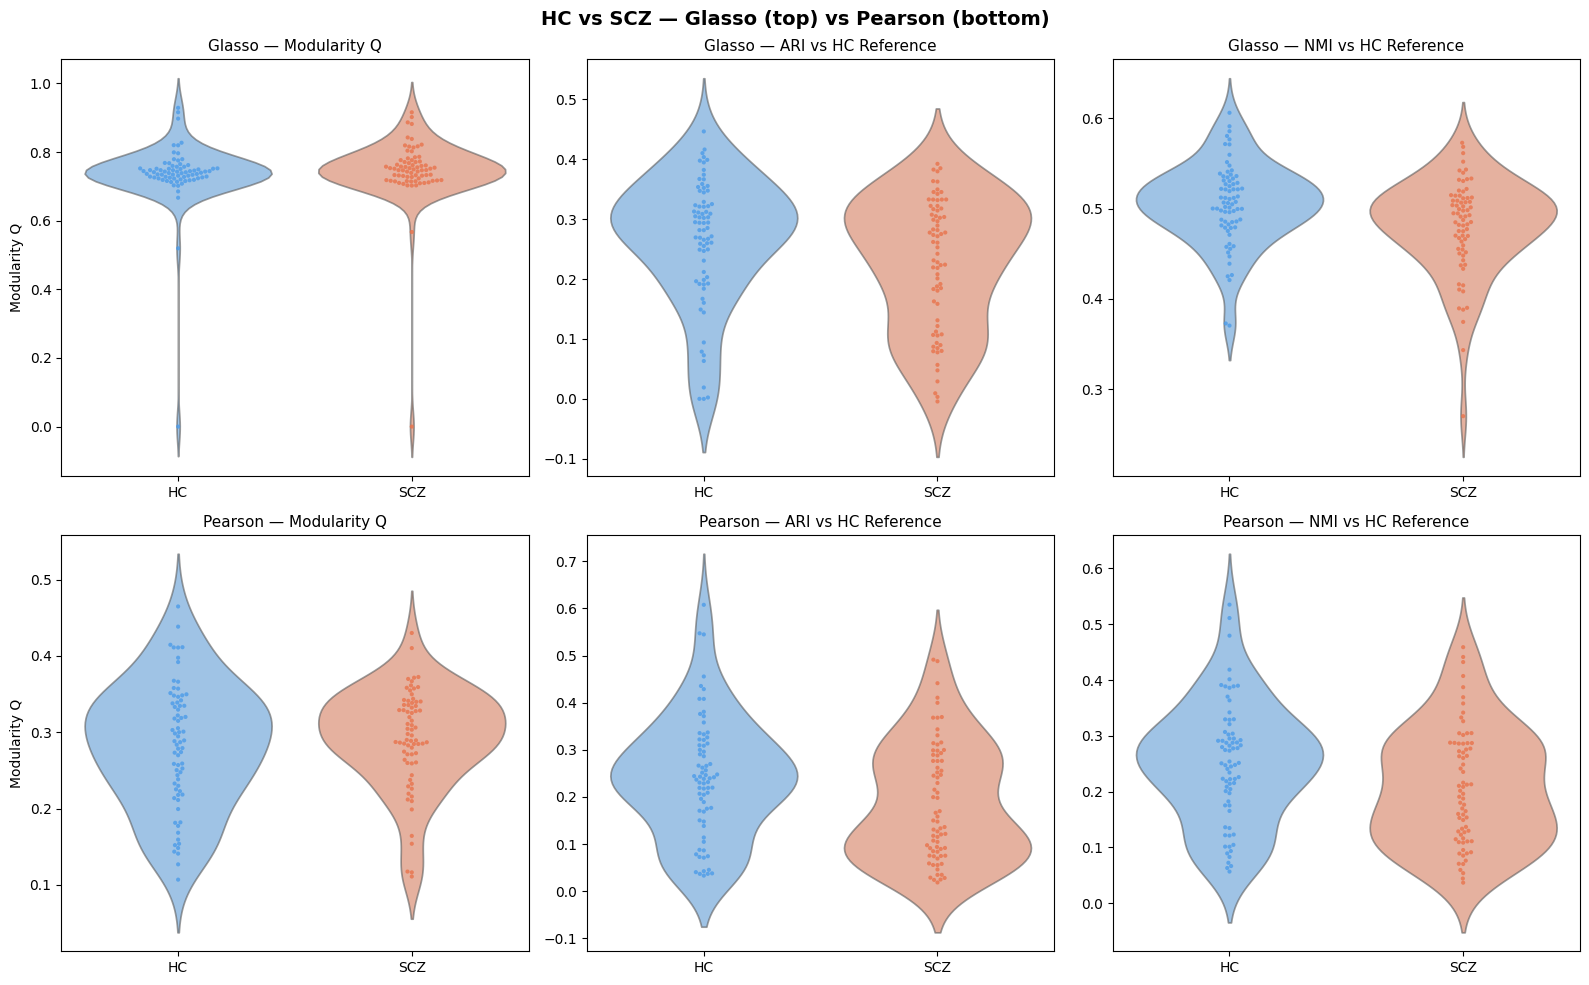

In [105]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('HC vs SCZ — Glasso (top) vs Pearson (bottom)',
             fontsize=14, fontweight='bold')

metrics_info = [
    ('q',   'Modularity Q'),
    ('ari', 'ARI vs HC Reference'),
    ('nmi', 'NMI vs HC Reference')
]

for row_idx, (method_name, dfm) in enumerate([('Glasso', df_glasso),
                                               ('Pearson', df_pearson)]):
    for col_idx, (metric, ylabel) in enumerate(metrics_info):
        ax = axes[row_idx, col_idx]
        sns.violinplot(data=dfm, x='group', y=metric, palette=PALETTE,
                       order=['HC','SCZ'], inner=None, ax=ax, alpha=0.6)
        sns.swarmplot(data=dfm, x='group', y=metric, palette=PALETTE,
                      order=['HC','SCZ'], size=3, ax=ax, alpha=0.8)
        ax.set_title(f'{method_name} — {ylabel}', fontsize=11)
        ax.set_xlabel('')
        ax.set_ylabel(ylabel if col_idx == 0 else '')

plt.tight_layout()
plt.savefig('fig1_q_distribution_dual.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Cell 8) Identify Spurious Inter-Community Edges

An edge (i, j) is 'spurious' in a given SCZ subject if:
- ROI i and ROI j belong to **different communities in the HC reference partition**
- The edge weight |w(i,j)| in the SCZ subject is significantly higher than the HC group average |w(i,j)|

**Algorithm:**
1. For every pair (i, j) with i < j (upper triangle only, to avoid double-counting),
   determine whether they are in the same or different HC reference communities.
2. Compute the HC mean and SD of |w(i,j)| across all HC subjects.
3. For each SCZ subject, compute the z-score of |w(i,j)| relative to the HC distribution.
4. A z-score > 2.0 flags the edge as 'spuriously strong' in that subject.
5. For each ROI, count how many spurious inter-community edges it participates in
   across all SCZ subjects — this is the **bridge score** of that node.

In [110]:
def detect_bridge_edges(matrices_hc, matrices_scz, hc_ref_partition,
                        valid_roi_mask, z_threshold=2.0):
    """
    Identify spurious inter-community edges in each SCZ subject relative to
    the HC reference partition.

    Returns
    -------
    bridge_counts : np.ndarray of shape (N_ROI,)
        Total spurious-edge count per ROI across all SCZ subjects.
    scz_spurious_edges : list of length N_SCZ
        Each entry is a list of (i, j, z_score) tuples sorted by z descending.
    """
    
    n= matrices_hc.shape[1]
    
    #HC mean and std of |edge weight| for every (i,j) pair
    hc_mean_abs = np.abs(matrices_hc).mean(axis=0)
    hc_std_abs = np.abs(matrices_hc).std(axis=0)
    hc_std_abs[hc_std_abs < 1e-10] = 1e-10 #avoid divide by 0
    
    nodes = sorted(hc_ref_partition.keys())
    cross_mask = np.zeros((n,n), dtype = bool)
    for ii in range(n):
        for jj in range (ii+1, n):
            if not valid_roi_mask[ii] or not valid_roi_mask[jj]:
                continue #skip artifact ROI
            if hc_ref_partition[nodes[ii]] != hc_ref_partition[nodes[jj]]:
                cross_mask[ii,jj] = True
        
    bridge_counts = np.zeros(n)
    scz_spurious_edges= []
    
    for A_scz in matrices_scz:
        A_abs = np.abs(A_scz)
        z_matrix = (A_abs - hc_mean_abs) / hc_std_abs
        spurious_mask = cross_mask & (z_matrix > z_threshold)
        
        ij_pairs = np.argwhere(spurious_mask)
        subj_edges= sorted(
            [(i,j, z_matrix[i,j]) for i,j in ij_pairs],
            key= lambda x: -x[2]
        )
        scz_spurious_edges.append(subj_edges)
        
        for i,j, _ in subj_edges:
            bridge_counts[i] += 1
            bridge_counts[j] += 1
            
    return bridge_counts, scz_spurious_edges

In [132]:
# RUN BRIDGE DETECTION
SPURIOUS_Z_THRESHOLD = 2.0


print('detecting spurious bridges in GLASSO...')
bridge_counts_glasso, scz_spurious_edges_glasso = detect_bridge_edges(
    matrices_hc_glasso, 
    matrices_scz_glasso, 
    hc_ref_partition_glasso ,
    VALID_ROI_MASK, 
    z_threshold=SPURIOUS_Z_THRESHOLD
)




print('detecting spurious bridges in PEARSON...')
bridge_counts_pearson, scz_spurious_edges_pearson = detect_bridge_edges(
    matrices_hc_pearson, 
    matrices_scz_pearson, 
    hc_ref_partition_pearson ,
    VALID_ROI_MASK, 
    z_threshold=SPURIOUS_Z_THRESHOLD
)





# Summary for both
for method, counts, label_set in [
    ('GLASSO',  bridge_counts_glasso,  'direct connectivity'),
    ('PEARSON', bridge_counts_pearson, 'total connectivity')
]:
    top10_idx    = np.argsort(counts)[::-1][:10]
    print(f'\n=== {method} ({label_set}) — top 10 bridge ROIs ===')
    for i in top10_idx:
        print(f'  {all_labels[i]:<55s}  bridge score count = {int(counts[i])}')

detecting spurious bridges in GLASSO...
detecting spurious bridges in PEARSON...

=== GLASSO (direct connectivity) — top 10 bridge ROIs ===
  7Networks_RH_Cont_Temp_3                                 bridge score count = 627
  7Networks_RH_Default_Temp_3                              bridge score count = 528
  7Networks_LH_SalVentAttn_ParOper_5                       bridge score count = 520
  7Networks_RH_Default_PFCv_6                              bridge score count = 481
  7Networks_LH_Cont_Temp_3                                 bridge score count = 464
  7Networks_RH_Cont_PFCl_29                                bridge score count = 453
  7Networks_LH_DorsAttn_Post_6                             bridge score count = 453
  7Networks_RH_Default_Temp_10                             bridge score count = 447
  7Networks_RH_Cont_PFCl_30                                bridge score count = 441
  7Networks_RH_Default_Par_13                              bridge score count = 436

=== PEARSON (total 

## Cell 9) VISUALIZATION 2 Bridge node map on 3D brain (Glasso + Pearson)

2 panels per method:
- panel A: HC ref partition
- panel B: SCZ spurious bridges (node size= bridge score, edges = top spurious)

Glasso bridges= direct pathological connections

Pearson bridges= pathological indirect-pathway connections

# Visualization choices:
- 1. plot_connectome renders each ROI as a discrete node. We later use plot_stat_map for the smooth bridge-score density view
- 2. Glass-brain ortho display ( 3 views: sagittal, coronal, axial)
- 3. node color = HC reference community membership: lets us see which canonical network each ROI belongs to. The same color in the SCZ panel marks ROIs that should be in that community per healthy ref, even if the SCZ participation assigns them differently
- 4. node size = bridge count (in SCZ panel only), emphasising on the most pathologically "overflowing" nodes. Top 10 are labelled.
- 5. Top 30 spurious edges (by mean z-score across all SCZ) shown as red lines


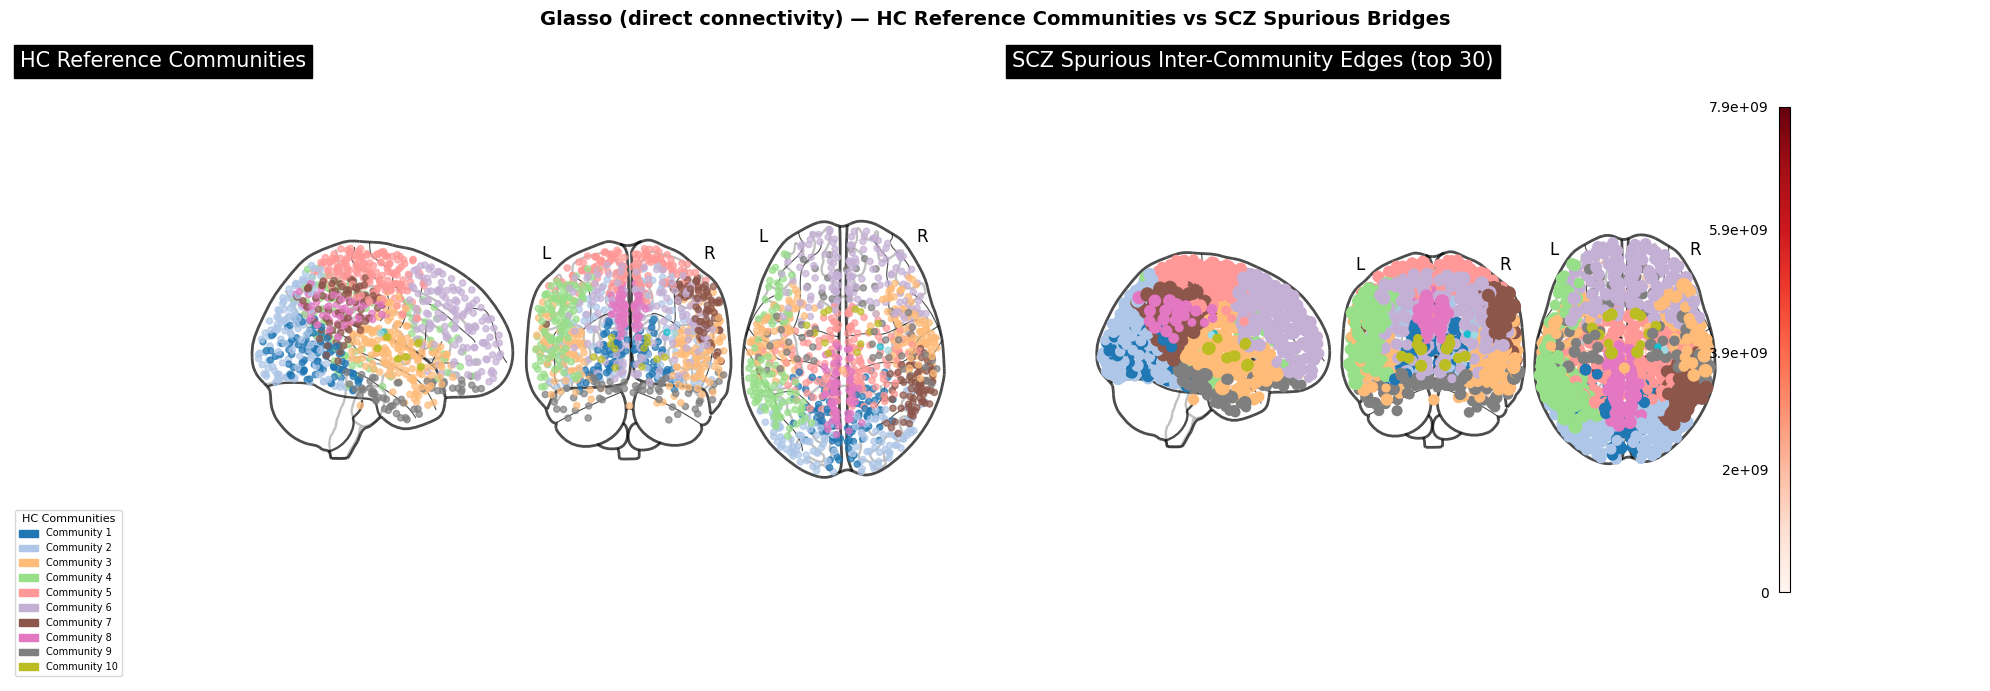

Saved: fig2_brain_communities_glasso.png



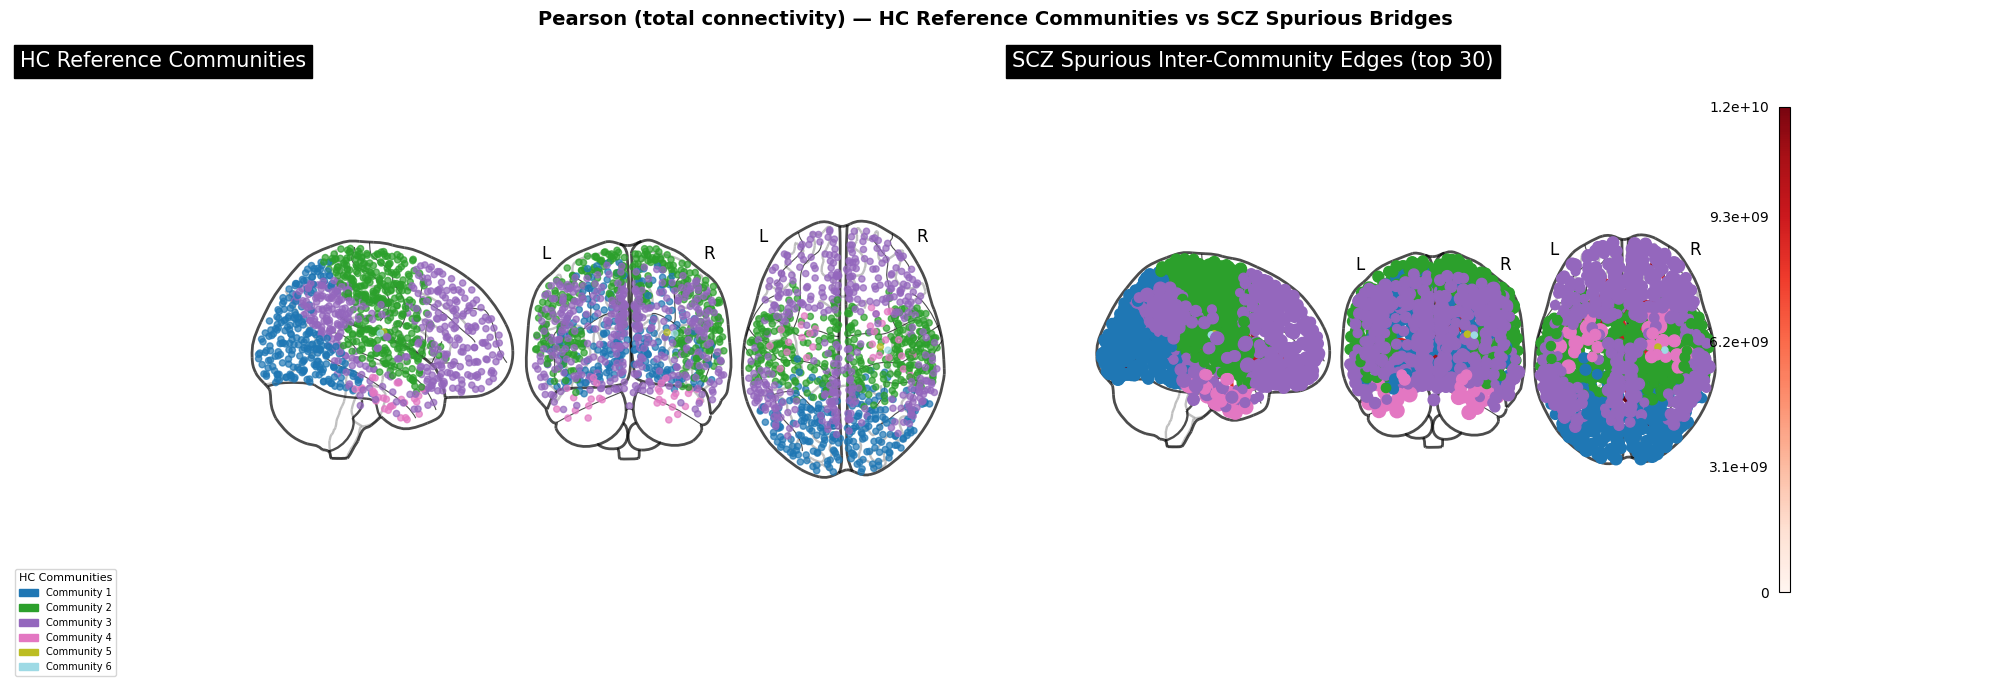

Saved: fig2_brain_communities_pearson.png


In [128]:
#helper to produce one method's two-panel figure 
def plot_bridge_map(
    method_name,
    bridge_counts,
    scz_spurious_edges,
    hc_ref_partition,
    valid_roi_mask,
    coords,
    labels,
    n_top_edges=30,
    save_path=None
):
    n = len(coords)

    bridge_counts_masked = bridge_counts.copy()
    bridge_counts_masked[~valid_roi_mask] = 0

    # Build community colour map (was missing in the second version)
    community_ids = sorted(set(hc_ref_partition.values()))
    cmap_comm     = plt.cm.get_cmap('tab20', len(community_ids))
    comm_colour   = {cid: cmap_comm(i) for i, cid in enumerate(community_ids)}

    node_colours = np.array([
        comm_colour[hc_ref_partition[i]][:3]
        for i in range(n)
    ])

    base_size = 20
    max_bridge = bridge_counts_masked.max() if bridge_counts_masked.max() > 0 else 1
    bridge_size = base_size + (bridge_counts_masked / max_bridge) * 100

    edge_z_sums   = defaultdict(float)
    edge_z_counts = Counter()
    for subj_edges in scz_spurious_edges:
        for i, j, z in subj_edges:
            if not valid_roi_mask[i] or not valid_roi_mask[j]:
                continue
            key = (min(i, j), max(i, j))
            edge_z_sums[key]   += z
            edge_z_counts[key] += 1

    edge_combined_score = {
        k: (edge_z_sums[k] / edge_z_counts[k]) * np.log1p(edge_z_counts[k])
        for k in edge_z_sums
    }

    top_edges = sorted(edge_combined_score.items(), key=lambda x: -x[1])[:n_top_edges]

    spurious_adj = np.zeros((n, n))
    for (i, j), score in top_edges:
        spurious_adj[i, j] = score
        spurious_adj[j, i] = score

    fig, axes = plt.subplots(1, 2, figsize=(20, 7))
    fig.suptitle(
        f'{method_name} — HC Reference Communities vs SCZ Spurious Bridges',
        fontsize=14, fontweight='bold'
    )

# PANEL A — HC reference (use plot_markers, no edges at all) ------------------------------------------
    # plot_connectome has a known bug in some nilearn versions where it
    # tries to set up an edge colorbar even when no edges should render,
    # crashing with "GlassBrainAxes has no attribute cmap".
    # plot_markers is the purpose-built nilearn function for node-only
    # displays and does not invoke any edge/colorbar machinery.
    #
    # plot_markers requires:
    #   - node_values: scalar per node (used as colour input by default)
    #   - node_cmap:   colormap to map values to colours
    # To get our discrete community colours, we pass each node's community ID
    # as the value and use a discrete colormap built from comm_colour.
    
    
    # node_values: integer community ID per node, remapped to 0..K-1
    node_values = np.array([
        community_ids.index(hc_ref_partition[i])
        for i in range(n)
    ])
    
    # discrete colormap matching our community colour scheme
    discrete_cmap = ListedColormap([cmap_comm(i) for i in range(len(community_ids))])
    
    plotting.plot_markers(
        node_values  = node_values,
        node_coords  = coords,
        node_size    = base_size,
        node_cmap    = discrete_cmap,
        node_vmin    = 0,
        node_vmax    = len(community_ids) - 1,
        display_mode = 'ortho',
        axes         = axes[0],
        title        = 'HC Reference Communities',
        colorbar     = False
    )

    # PANEL B — SCZ spurious bridges ---------------------------------------------------------------
    plotting.plot_connectome(
        adjacency_matrix = spurious_adj,
        node_coords      = coords,
        node_color       = node_colours,
        node_size        = bridge_size,
        edge_cmap        = 'Reds',
        edge_vmin        = 0,
        edge_vmax        = spurious_adj.max() if spurious_adj.max() > 0 else 1,
        display_mode     = 'ortho',
        axes             = axes[1],
        title            = f'SCZ Spurious Inter-Community Edges (top {n_top_edges})'
    )

    n_legend = min(len(community_ids), 10)
    patches = [
        mpatches.Patch(color=cmap_comm(i), label=f'Community {i+1}')
        for i in range(n_legend)
    ]
    axes[0].legend(
        handles=patches, loc='lower left', fontsize=7,
        title='HC Communities', title_fontsize=8
    )

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()




#  Render Glasso brain map 
plot_bridge_map(
    method_name        = 'Glasso (direct connectivity)',
    bridge_counts      = bridge_counts_glasso,
    scz_spurious_edges = scz_spurious_edges_glasso,
    hc_ref_partition   = hc_ref_partition_glasso,
    valid_roi_mask     = VALID_ROI_MASK,
    coords             = all_coords,
    labels             = all_labels,
    n_top_edges        = 30,
    save_path          = 'fig2_brain_communities_glasso.png'
)
print('Saved: fig2_brain_communities_glasso.png\n')



#  Render Pearson brain map 
if 'bridge_counts_pearson' in dir():
    plot_bridge_map(
        method_name        = 'Pearson (total connectivity)',
        bridge_counts      = bridge_counts_pearson,
        scz_spurious_edges = scz_spurious_edges_pearson,
        hc_ref_partition   = hc_ref_partition_pearson,
        valid_roi_mask     = VALID_ROI_MASK,
        coords             = all_coords,
        labels             = all_labels,
        n_top_edges        = 30,
        save_path          = 'fig2_brain_communities_pearson.png'
    )
    print('Saved: fig2_brain_communities_pearson.png')


---
## Cell 10) VISUALISATION 3: Bridge Node Bar Chart (Top 15 ROIs)

A horizontal bar chart where each bar = one brain region,
bar length = its total bridge count across all SCZ subjects.
Bars are coloured by the HC community the region belongs to,
so you can see whether bridge nodes come from specific networks.

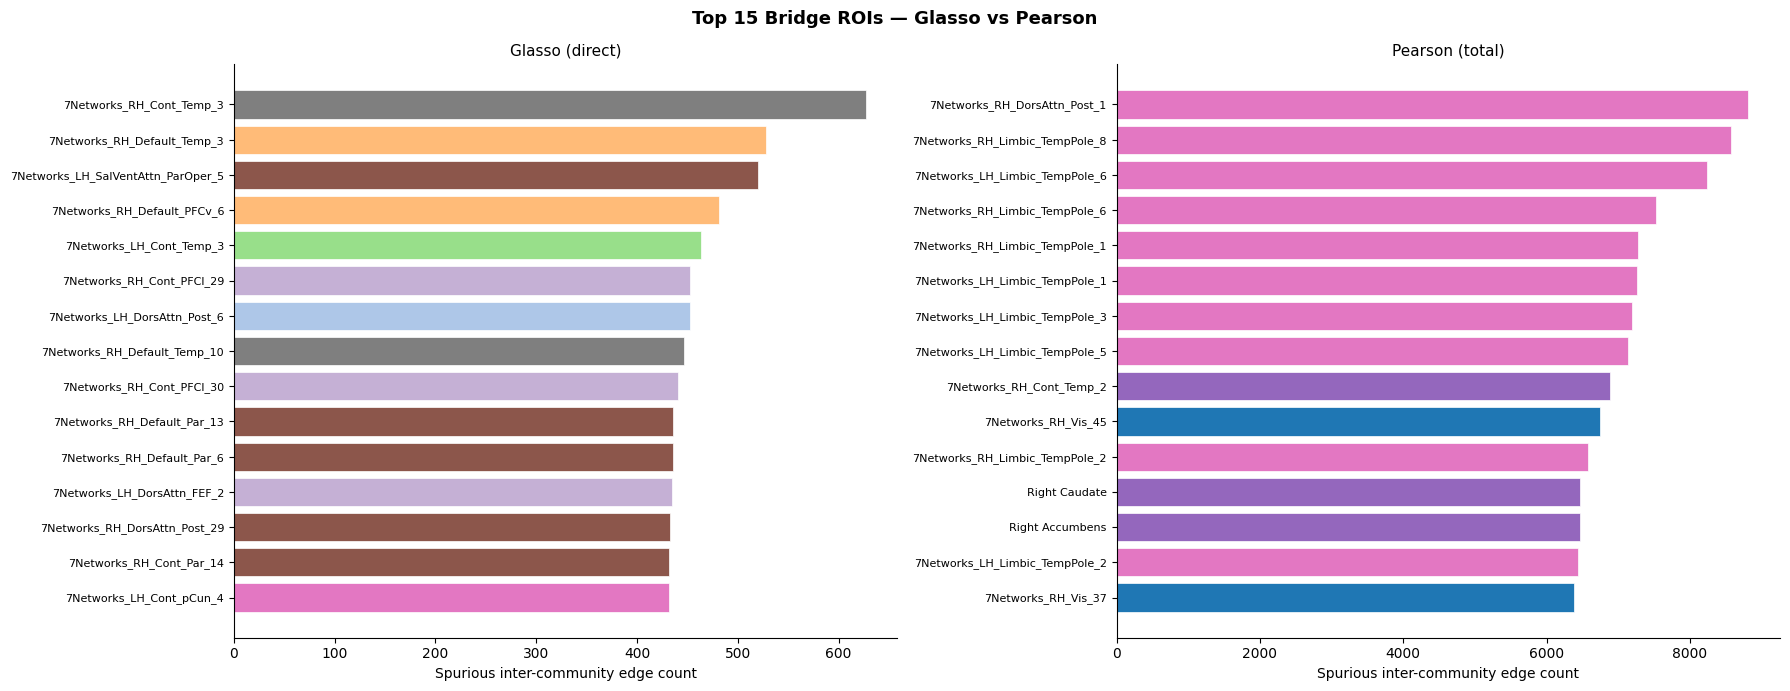

In [130]:
TOP_N = 15
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(f'Top {TOP_N} Bridge ROIs — Glasso vs Pearson',
             fontsize=13, fontweight='bold')

for ax, method_name, counts, ref_partition in [
    (axes[0], 'Glasso (direct)',   bridge_counts_glasso,  hc_ref_partition_glasso),
    (axes[1], 'Pearson (total)',   bridge_counts_pearson, hc_ref_partition_pearson)
]:
    top_idx     = np.argsort(counts)[::-1][:TOP_N]
    top_names   = [all_labels[i] for i in top_idx]
    top_scores  = counts[top_idx]
    community_ids = sorted(set(ref_partition.values()))
    cmap_comm   = plt.cm.get_cmap('tab20', len(community_ids))
    comm_colour = {cid: cmap_comm(i) for i, cid in enumerate(community_ids)}
    top_colours = [comm_colour[ref_partition[i]] for i in top_idx]

    ax.barh(range(TOP_N), top_scores[::-1],
            color=top_colours[::-1], edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(TOP_N))
    ax.set_yticklabels(top_names[::-1], fontsize=8)
    ax.set_xlabel('Spurious inter-community edge count', fontsize=10)
    ax.set_title(method_name, fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig3_bridge_nodes_dual.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#  Edge count diagnostic for both methods 
# Counts the total possible edges, the total inter-community ("crossing") edges,
# and the spurious-edge counts from the bridge detection step.

def edge_count_diagnostic(method_name, hc_ref_partition, scz_spurious_edges,
                          matrices_hc, matrices_scz, valid_roi_mask):
    """
    Print a breakdown of edge counts for one method:
      - Total possible undirected edges between valid ROIs
      - Within-community vs cross-community edges in the HC reference
      - Average non-zero edges per HC and SCZ subject (graph density)
      - Average spurious cross-community edges per SCZ subject
      - Spurious-as-fraction-of-cross-community (the meaningful normalised rate)
    """
    n = len(hc_ref_partition)
    valid_count = int(valid_roi_mask.sum())

    # ── Theoretical maximum ─────────────────────────────────────────────────
    # Undirected edges between valid ROIs only (excluding the artefact ROIs)
    total_possible_edges = valid_count * (valid_count - 1) // 2

    # ── Within-community vs cross-community split (in the reference) ────────
    within_count = 0
    cross_count  = 0
    nodes = sorted(hc_ref_partition.keys())
    for ii in range(n):
        if not valid_roi_mask[ii]:
            continue
        for jj in range(ii + 1, n):
            if not valid_roi_mask[jj]:
                continue
            if hc_ref_partition[nodes[ii]] == hc_ref_partition[nodes[jj]]:
                within_count += 1
            else:
                cross_count += 1

    # ── Average non-zero edges per subject (graph density) ──────────────────
    # Counted on each subject's actual matrix (after thresholding/masking),
    # not on the theoretical full graph.
    def avg_nonzero_edges(matrices):
        edges_per_subj = []
        for A in matrices:
            # Upper triangle only, exclude artefact rows/cols
            n_edges = 0
            for c in range(A.shape[0]):
                if not valid_roi_mask[c]:
                    continue
                for r in range(c):
                    if not valid_roi_mask[r]:
                        continue
                    if A[r, c] != 0:
                        n_edges += 1
            edges_per_subj.append(n_edges)
        return np.mean(edges_per_subj)

    avg_edges_hc  = avg_nonzero_edges(matrices_hc)
    avg_edges_scz = avg_nonzero_edges(matrices_scz)

    # ── Spurious edges per SCZ subject (from bridge detection) ──────────────
    spurious_per_subj = [len(s) for s in scz_spurious_edges]
    avg_spurious      = np.mean(spurious_per_subj)
    total_spurious    = sum(spurious_per_subj)

    # ── Print breakdown ─────────────────────────────────────────────────────
    print(f'\n=== {method_name} edge count diagnostic ===')
    print(f'Valid ROIs                            : {valid_count:>10,}')
    print(f'Theoretical max edges (valid ROIs)    : {total_possible_edges:>10,}')
    print(f'  within-community  (in HC reference) : {within_count:>10,} '
          f'({within_count / total_possible_edges:>6.1%})')
    print(f'  cross-community   (in HC reference) : {cross_count:>10,} '
          f'({cross_count / total_possible_edges:>6.1%})')
    print()
    print(f'Avg non-zero edges per HC  subject    : {avg_edges_hc:>10,.0f} '
          f'({avg_edges_hc / total_possible_edges:>6.1%} of max)')
    print(f'Avg non-zero edges per SCZ subject    : {avg_edges_scz:>10,.0f} '
          f'({avg_edges_scz / total_possible_edges:>6.1%} of max)')
    print()
    print(f'Avg spurious cross-comm edges / SCZ   : {avg_spurious:>10,.1f} '
          f'({avg_spurious / cross_count:>6.2%} of cross-comm pool)')
    print(f'Total spurious edges (all SCZ subj)   : {total_spurious:>10,}')


# ── Run for both methods ─────────────────────────────────────────────────────
edge_count_diagnostic(
    method_name        = 'GLASSO',
    hc_ref_partition   = hc_ref_partition_glasso,
    scz_spurious_edges = scz_spurious_edges_glasso,
    matrices_hc        = matrices_hc_glasso,
    matrices_scz       = matrices_scz_glasso,
    valid_roi_mask     = VALID_ROI_MASK,
)

edge_count_diagnostic(
    method_name        = 'PEARSON',
    hc_ref_partition   = hc_ref_partition_pearson,
    scz_spurious_edges = scz_spurious_edges_pearson,
    matrices_hc        = matrices_hc_pearson,
    matrices_scz       = matrices_scz_pearson,
    valid_roi_mask     = VALID_ROI_MASK,
)


=== GLASSO edge count diagnostic ===
Valid ROIs                            :      1,017
Theoretical max edges (valid ROIs)    :    516,636
  within-community  (in HC reference) :     63,078 ( 12.2%)
  cross-community   (in HC reference) :    453,558 ( 87.8%)

Avg non-zero edges per HC  subject    :      5,542 (  1.1% of max)
Avg non-zero edges per SCZ subject    :      5,250 (  1.0% of max)

Avg spurious cross-comm edges / SCZ   :    1,550.1 ( 0.34% of cross-comm pool)
Total spurious edges (all SCZ subj)   :    111,609

=== PEARSON edge count diagnostic ===
Valid ROIs                            :      1,017
Theoretical max edges (valid ROIs)    :    516,636
  within-community  (in HC reference) :    168,905 ( 32.7%)
  cross-community   (in HC reference) :    347,731 ( 67.3%)

Avg non-zero edges per HC  subject    :    152,829 ( 29.6% of max)
Avg non-zero edges per SCZ subject    :    131,914 ( 25.5% of max)

Avg spurious cross-comm edges / SCZ   :   23,603.7 ( 6.79% of cross-comm pool